### LIBRARY IMPORTS

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### CROSS-VALIDATION

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, kf, processor):
    mse_scores = []
    r2_scores = []
    oof_preds = np.zeros(len(data))

    for train_idx, valid_idx in kf.split(data):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        oof_preds[valid_idx] = preds

        fold_mse = mean_squared_error(y_valid, preds)
        fold_r2 = r2_score(y_valid, preds)
        
        mse_scores.append(fold_mse)
        r2_scores.append(fold_r2)
    
    return mse_scores, r2_scores, oof_preds

### RIDGE REGRESSION

In [6]:
ridge = Ridge(alpha=1)
ridge_mse_scores, ridge_r2_scores, ridge_oof_preds = my_cross_validation(ridge, raw_train, target, kf, processor)

### DECISION TREE

In [31]:
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_mse_scores, dt_r2_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, kf, processor)

### RANDOM FOREST

In [32]:
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_mse_scores, rf_r2_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, kf, processor)

### NEURAL NETWORK

In [20]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        
        input_size = X_train.shape[1]
        output_size = y_train.shape[1] if len(y_train.shape) > 1 else 1
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.float32).view(-1, output_size).to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.view_as(preds))
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                val_preds_np = val_preds.cpu().numpy().flatten()
                y_valid_np = y_valid_t.cpu().numpy().flatten()
                val_r2 = r2_score(y_valid_np, val_preds_np)

            if (epoch+1) % 10 == 0:
                print(f"Epoch: {epoch+1} | Validation MSE: {val_loss:.4f} | R^2: {val_r2:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                print("-"*50)
                break
                
        if best_model:
            self.load_state_dict(best_model)

In [22]:
mlp = MLP(epochs=100, learning_rate=0.0001, hidden_size=[16, 8], batch_size=256)

mlp_mse_scores = []
mlp_r2_scores = []
mlp_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = mlp.predict(X_valid.values).ravel()
    mlp_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    mlp_mse_scores.append(fold_mse)
    mlp_r2_scores.append(fold_r2)

Epoch: 10 | Validation MSE: 0.1057 | R^2: 0.7796
Epoch: 20 | Validation MSE: 0.1054 | R^2: 0.7801
Epoch: 30 | Validation MSE: 0.1053 | R^2: 0.7803
Epoch: 40 | Validation MSE: 0.1053 | R^2: 0.7804
Epoch: 50 | Validation MSE: 0.1053 | R^2: 0.7803
Epoch: 60 | Validation MSE: 0.1052 | R^2: 0.7806
Epoch: 70 | Validation MSE: 0.1052 | R^2: 0.7805
--------------------------------------------------
Epoch: 10 | Validation MSE: 0.1075 | R^2: 0.7779
Epoch: 20 | Validation MSE: 0.1074 | R^2: 0.7780
Epoch: 30 | Validation MSE: 0.1073 | R^2: 0.7782
--------------------------------------------------
Epoch: 10 | Validation MSE: 0.1051 | R^2: 0.7786
Epoch: 20 | Validation MSE: 0.1046 | R^2: 0.7795
Epoch: 30 | Validation MSE: 0.1046 | R^2: 0.7797
Epoch: 40 | Validation MSE: 0.1045 | R^2: 0.7797
Epoch: 50 | Validation MSE: 0.1045 | R^2: 0.7797
Epoch: 60 | Validation MSE: 0.1045 | R^2: 0.7798
Epoch: 70 | Validation MSE: 0.1045 | R^2: 0.7797
--------------------------------------------------
Epoch: 10 | Va

### VISUALIZATION

C:\Users\oriol\AppData\Local\Temp\ipykernel_12064\3874620265.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=melted_df, x='Model', y='MSE', palette='viridis', size=6)


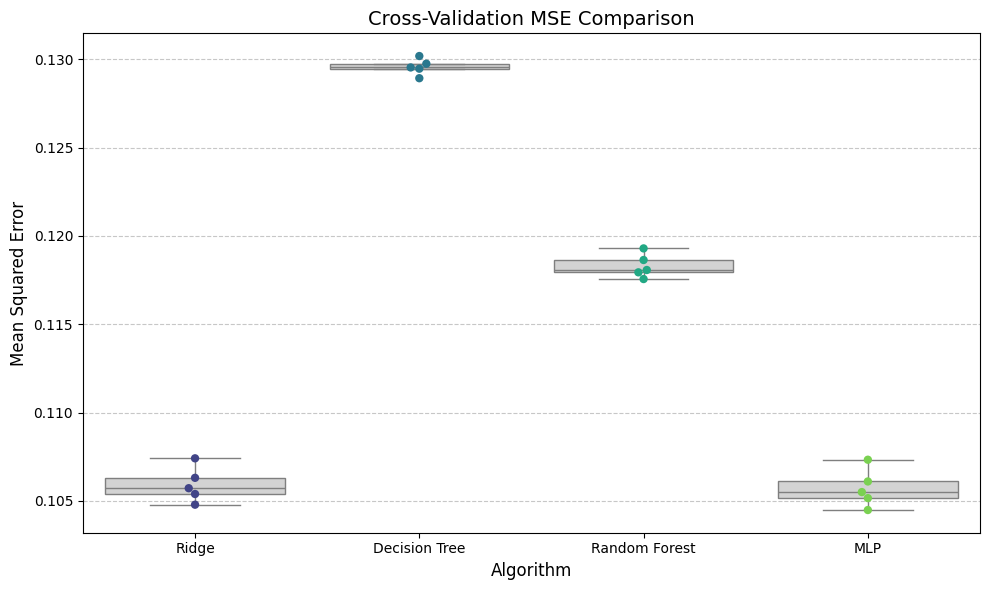

In [ ]:
# 1. Prepare the data for Seaborn (Long-format)
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'MLP': mlp_mse_scores
})

# Melt the dataframe so it has two columns: 'Model' and 'MSE'
melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Plotting
plt.figure(figsize=(10, 6))

# Add a boxplot to show the quartiles/median
sns.boxplot(data=melted_df, x='Model', y='MSE', color='lightgray', showfliers=False)

# Overlay the swarmplot to show the individual fold scores
sns.swarmplot(data=melted_df, x='Model', y='MSE', palette='viridis', size=6)

plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()